<a href="https://colab.research.google.com/github/surajsarkar3526-cyber/MachineLearning/blob/main/Model_Evaluation%2C_Confusion_Matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model evaluation is crucial to assess how well a machine learning model generalizes to unseen data.

##Confusion Matrix:

A confusion matrix is a 2x2 table used to evaluate the performance of a binary classification model by comparing actual vs. predicted classes.

##Classification Report:

The classification report summarizes a model’s performance using key metrics: precision (correct positive predictions), recall (correctly identified actual positives), F1-score (balance between precision and recall), and support (number of true instances for each class). It gives a detailed view of how well the model performs per class.

##Load Dataset

In [3]:
import pandas as pd
df = pd.read_csv("binary_classification_sample.csv")
df

,Age,Salary,Experience,Gender,Department,Education,LocationScore,Purchased
0,56,51905.183591,27,Female,HR,Bachelors,67.964728,0
1,69,31258.344158,16,Female,Engineering,High School,21.825389,0
2,46,79176.734217,4,Male,HR,PhD,94.996118,0
3,32,47699.953137,4,Male,Engineering,High School,78.634501,1
4,60,36395.191619,5,Male,Marketing,High School,8.941100,1
...,...,...,...,...,...,...,...,...
195,69,69228.805705,10,Female,Engineering,Bachelors,77.985099,1
196,30,49573.678136,14,Female,Marketing,Bachelors,3.961883,1
197,58,24253.633311,27,Female,HR,High School,48.050695,0
198,20,NaN,12,Female,Sales,High School,NaN,0


##Data Preprocessing and Cleaning

In [4]:
df.dropna(inplace=True)

##Encoding

In [5]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

df['Gender'] = encoder.fit_transform(df[['Gender']]).astype(int)
df['Education'] = encoder.fit_transform(df[['Education']]).astype(int)
df['Department'] = encoder.fit_transform(df[['Department']]).astype(int)
df

,Age,Salary,Experience,Gender,Department,Education,LocationScore,Purchased
0,56,51905.183591,27,0,1,0,67.964728,0
1,69,31258.344158,16,0,0,1,21.825389,0
2,46,79176.734217,4,1,1,3,94.996118,0
3,32,47699.953137,4,1,0,1,78.634501,1
4,60,36395.191619,5,1,2,1,8.941100,1
...,...,...,...,...,...,...,...,...
194,44,33125.723933,13,1,3,3,86.012240,1
195,69,69228.805705,10,0,0,0,77.985099,1
196,30,49573.678136,14,0,2,0,3.961883,1
197,58,24253.633311,27,0,1,1,48.050695,0


##Train test split

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('Purchased', axis=1)
y = df['Purchased']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Model Training and Evaluation

accuracy 0.5
confusoin matrix 
 [[10  7]
 [10  7]]
classification report
                precision    recall  f1-score   support

           0       0.50      0.59      0.54        17
           1       0.50      0.41      0.45        17

    accuracy                           0.50        34
   macro avg       0.50      0.50      0.50        34
weighted avg       0.50      0.50      0.50        34



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


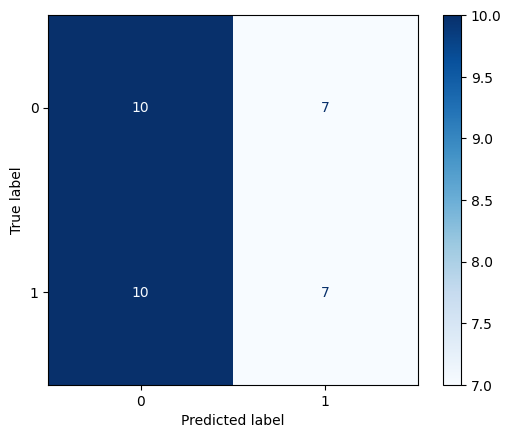

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


lg = LogisticRegression()

lg.fit(X_train, y_train)

y_pred = lg.predict(X_test)

print("accuracy", accuracy_score(y_test, y_pred))
print("confusoin matrix \n", confusion_matrix(y_test,y_pred))
print("classification report\n ",classification_report(y_test, y_pred))

cm = confusion_matrix(y_test,y_pred)
dist = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lg.classes_)
dist.plot(cmap = plt.cm.Blues)

Confusion Matrix:
 [[ 9  8]
 [ 7 10]]
Accuracy Score: 0.5588235294117647

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.53      0.55        17
           1       0.56      0.59      0.57        17

    accuracy                           0.56        34
   macro avg       0.56      0.56      0.56        34
weighted avg       0.56      0.56      0.56        34



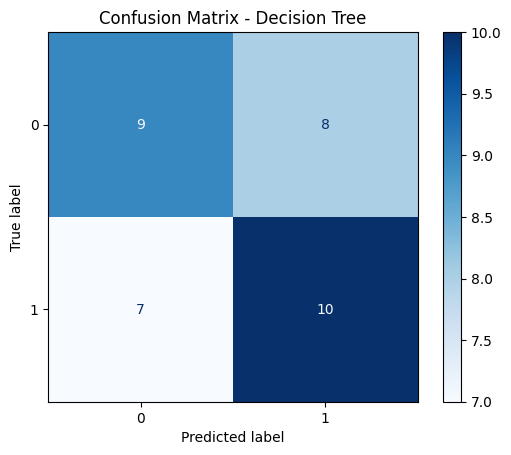

In [16]:
# Try for Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Train Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Print accuracy and classification report
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix using dc
dc = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dc.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree")
plt.show()